In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    roc_auc_score, accuracy_score, confusion_matrix,
    classification_report, RocCurveDisplay
)
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [2]:
def find_target_col(df):
    for c in df.columns:
        if c == "Churn":
            return c
    for c in df.columns:
        if "churn" in c.lower():
            return c
    raise ValueError("No churn-like target column found.")

def to_binary(series: pd.Series) -> pd.Series:
    if series.dtype.name == "category":
        series = series.astype(str)
    if series.dtype == bool:
        return series.astype(int)
    s = series.astype(str).str.strip().str.lower()
    true_vals = {"yes", "true", "1", "churned", "y", "t"}
    return s.isin(true_vals).astype(int)

In [3]:
train_path = "cell2celltrain.csv"
holdout_path = "cell2cellholdout.csv"

train_data = pd.read_csv(train_path)
holdout_data = pd.read_csv(holdout_path)

target = find_target_col(train_data)
y = to_binary(train_data[target])

id_like = [c for c in train_data.columns if "customerid" in c.lower()]
features = [c for c in train_data.columns if c not in {target, *id_like}]
X = train_data[features]
X_holdout = holdout_data[[c for c in holdout_data.columns if c in features]]

numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
X = X[numeric_cols]
X_holdout = X_holdout[numeric_cols]

In [4]:
preprocess = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

clf = LogisticRegression(
    penalty="l2",
    solver="saga",
    max_iter=5000,
    n_jobs=-1,
    class_weight="balanced",
    random_state=42,
)

pipe = Pipeline([
    ("prep", preprocess),
    ("clf", clf),
])

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

pipe.fit(X_train, y_train)

val_probs = pipe.predict_proba(X_val)[:, 1]
val_preds = (val_probs >= 0.5).astype(int)


=== Validation Results ===
AUC:       0.6074
Accuracy:  0.5806
Confusion matrix:
 [[4265 3003]
 [1279 1663]]

Classification report:
               precision    recall  f1-score   support

           0       0.77      0.59      0.67      7268
           1       0.36      0.57      0.44      2942

    accuracy                           0.58     10210
   macro avg       0.56      0.58      0.55     10210
weighted avg       0.65      0.58      0.60     10210



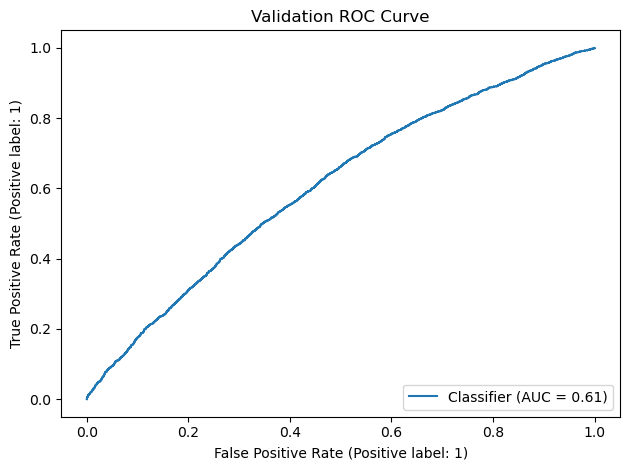


Saved: holdout_predictions_logreg_numeric.csv  Columns: ['CustomerID', 'prob', 'pred']


In [5]:
print("\n=== Validation Results ===")
print(f"AUC:       {roc_auc_score(y_val, val_probs):.4f}")
print(f"Accuracy:  {accuracy_score(y_val, val_preds):.4f}")
print("Confusion matrix:\n", confusion_matrix(y_val, val_preds))
print("\nClassification report:\n", classification_report(y_val, val_preds))

RocCurveDisplay.from_predictions(y_val, val_probs)
plt.title("Validation ROC Curve")
plt.tight_layout()
plt.show()

holdout_probs = pipe.predict_proba(X_holdout)[:, 1]
holdout_preds = (holdout_probs >= 0.5).astype(int)

customer_id_col = [c for c in holdout_data.columns if "customerid" in c.lower()][0]
out = holdout_data[[customer_id_col]].copy()
out["prob"] = holdout_probs
out["pred"] = holdout_preds
out.to_csv("holdout_predictions_logreg_numeric.csv", index=False)

print("\nSaved: holdout_predictions_logreg_numeric.csv  Columns:", list(out.columns))